In [6]:
# ============================
# CELL 1: Extract image features using ResNet50
# ============================

import os, pickle, torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm

def find_image_dir():
    base_input = '/kaggle/input'
    for root, dirs, files in os.walk(base_input):
        if len([f for f in files if f.endswith('.jpg')]) > 1000:
            return root
    return None

IMAGE_DIR = find_image_dir()
OUTPUT_FILE = 'flickr30k_features.pkl'

if IMAGE_DIR:
    print(f" Found images at: {IMAGE_DIR}")
else:
    raise FileNotFoundError("Dataset not found. Please add it.")

# ---------- Dataset ----------
class FlickrDataset(Dataset):
    def __init__(self, img_dir, transform):
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg'))]  # fixed tuple
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, name)
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), name

# ---------- Model ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# remove last classification layer -> output is 2048 feature vector
model = nn.Sequential(*list(model.children())[:-1])
model = nn.DataParallel(model).to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

dataset = FlickrDataset(IMAGE_DIR, transform)
# fixed: changed DataFrame to DataLoader
loader = DataLoader(dataset, batch_size=128, num_workers=2)   # reduced num_workers for Kaggle

features_dict = {}
with torch.no_grad():
    for img, names in tqdm(loader, desc="Extracting Features"):
        feats = model(img.to(device)).view(img.size(0), -1)
        for i, name in enumerate(names):
            features_dict[name] = feats[i].cpu().numpy()

with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(features_dict, f)

print(f"Success! {len(features_dict)} images processed. Saved to {OUTPUT_FILE}")

 Found images at: /kaggle/input/flickr30k/Images
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s] 
Extracting Features: 100%|██████████| 249/249 [02:44<00:00,  1.52it/s]


Success! 31783 images processed. Saved to flickr30k_features.pkl


**Loading the cached features**

In [7]:
# ============================
# CELL 2: Load the pre-computed features
# ============================

import pickle

with open('flickr30k_features.pkl', 'rb') as f:
    features_dict = pickle.load(f)

print(f"Loaded features for {len(features_dict)} images")

Loaded features for 31783 images


**Vocabulary from captions.txt**

In [9]:
# ============================
# CELL 3: Read captions and build vocabulary (FIXED)
# ============================

import pandas as pd
import re
from collections import Counter
import pickle   # <-- forgot this!

# Load captions file
captions_df = pd.read_csv('/kaggle/input/flickr30k/captions.txt')

# ---------- CLEANING: remove rows with missing captions ----------
print("Before cleaning:", captions_df.shape)
captions_df = captions_df.dropna(subset=['caption'])   # remove NaN
print("After cleaning:", captions_df.shape)
# -----------------------------------------------------------------

# Optional: convert to string just in case (some rows might be numbers)
captions_df['caption'] = captions_df['caption'].astype(str)

print("Captions head:")
print(captions_df.head())

# Simple tokenizer: lower case, remove non-letters, split
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.split()

# Count all words
word_counter = Counter()
for cap in captions_df['caption']:
    words = tokenize(cap)
    word_counter.update(words)

# Keep top 5000 words + 4 special tokens
vocab_size = 5000 + 4  # 5004
most_common = word_counter.most_common(5000)

# special tokens
SPECIAL_TOKENS = ['<pad>', '<start>', '<end>', '<unk>']
word2idx = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}  # 0,1,2,3
idx2word = {idx: token for token, idx in word2idx.items()}

# add top words
for idx, (word, _) in enumerate(most_common, start=4):   # start=4 because 0-3 are special
    word2idx[word] = idx
    idx2word[idx] = word

# Save vocabulary for later
with open('vocab.pkl', 'wb') as f:
    pickle.dump({'word2idx': word2idx, 'idx2word': idx2word}, f)

print(f"Vocabulary size: {len(word2idx)}")
print(f"First 10 words: {list(word2idx.items())[:10]}")

Before cleaning: (158915, 2)
After cleaning: (158914, 2)
Captions head:
            image                                            caption
0  1000092795.jpg   Two young guys with shaggy hair look at their...
1  1000092795.jpg   Two young , White males are outside near many...
2  1000092795.jpg   Two men in green shirts are standing in a yard .
3  1000092795.jpg       A man in a blue shirt standing in a garden .
4  1000092795.jpg            Two friends enjoy time spent together .
Vocabulary size: 5004
First 10 words: [('<pad>', 0), ('<start>', 1), ('<end>', 2), ('<unk>', 3), ('a', 4), ('in', 5), ('the', 6), ('on', 7), ('and', 8), ('man', 9)]


**Dataset that pairs image features with captions**

In [10]:
# ============================
# CELL 4: Create PyTorch Dataset for training
# ============================

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class FlickrCaptionDataset(Dataset):
    def __init__(self, features_dict, captions_df, word2idx, max_len=20):
        self.features = features_dict
        self.captions = captions_df
        self.word2idx = word2idx
        self.max_len = max_len

        # create list of (img_name, caption_indices)
        self.data_pairs = []
        for _, row in captions_df.iterrows():
            img_name = row['image']
            if img_name in self.features:
                cap = row['caption']
                tokens = tokenize(cap)[:max_len-2]   # leave room for <start> and <end>
                indices = [word2idx['<start>']] + \
                          [word2idx.get(w, word2idx['<unk>']) for w in tokens] + \
                          [word2idx['<end>']]
                self.data_pairs.append((img_name, indices))

    def __len__(self):
        return len(self.data_pairs)

    def __getitem__(self, idx):
        img_name, cap_indices = self.data_pairs[idx]
        feature = torch.tensor(self.features[img_name], dtype=torch.float32)  # (2048,)
        
        # pad or truncate to max_len
        if len(cap_indices) > self.max_len:
            cap_indices = cap_indices[:self.max_len-1] + [self.word2idx['<end>']]
        else:
            pad_len = self.max_len - len(cap_indices)
            cap_indices = cap_indices + [self.word2idx['<pad>']] * pad_len
        
        caption_tensor = torch.tensor(cap_indices, dtype=torch.long)
        return feature, caption_tensor

# Create dataset
dataset = FlickrCaptionDataset(features_dict, captions_df, word2idx, max_len=20)
print(f"Total (image, caption) pairs: {len(dataset)}")

# Split into train/val/test (80%,10%,10%)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Total (image, caption) pairs: 158914
Train: 127131, Val: 15891, Test: 15892


**Define Encoder, Decoder, and full model**

In [12]:
# ============================
# CELL 5: Seq2Seq Model
# ============================

import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=512):
        super().__init__()
        # project 2048 -> hidden_dim
        self.fc = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()

    def forward(self, features):
        # features: (batch, 2048)
        hidden = self.relu(self.fc(features))   # (batch, hidden_dim)
        return hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=word2idx['<pad>'])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, captions, hidden):
        # captions: (batch, seq_len)
        # hidden: (batch, hidden_dim) from encoder
        h0 = hidden.unsqueeze(0)   # (1, batch, hidden_dim)
        c0 = torch.zeros_like(h0)  # (1, batch, hidden_dim)
        
        embedded = self.embedding(captions)   # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embedded, (h0, c0))   # (batch, seq_len, hidden_dim)
        outputs = self.fc_out(lstm_out)        # (batch, seq_len, vocab_size)
        return outputs

class ImageCaptioningModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, features, captions):
        hidden = self.encoder(features)
        outputs = self.decoder(captions, hidden)
        return outputs

**Initialize model, loss, optimizer**

In [13]:
# ============================
# CELL 6: Training setup
# ============================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters (I tried a few values, these worked ok)
hidden_dim = 512
embed_dim = 256
num_epochs = 10   # you can increase later if overfitting is not bad
learning_rate = 0.001

encoder = Encoder(2048, hidden_dim)
decoder = Decoder(len(word2idx), embed_dim, hidden_dim)
model = ImageCaptioningModel(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Model ready")

Using device: cuda
Model ready


**Training loop (with validation)**

In [14]:
# ============================
# CELL 7: Train the model
# ============================

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for features, captions in train_loader:
        features = features.to(device)
        captions = captions.to(device)
        
        # forward: input = captions[:, :-1], target = captions[:, 1:]
        outputs = model(features, captions[:, :-1])
        loss = criterion(outputs.reshape(-1, len(word2idx)), captions[:, 1:].reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for features, captions in val_loader:
            features = features.to(device)
            captions = captions.to(device)
            outputs = model(features, captions[:, :-1])
            loss = criterion(outputs.reshape(-1, len(word2idx)), captions[:, 1:].reshape(-1))
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Save the model weights
torch.save(model.state_dict(), 'image_captioning_model.pth')
print("Model saved!")

Epoch 1/10 | Train Loss: 3.5368 | Val Loss: 3.0862
Epoch 2/10 | Train Loss: 2.9099 | Val Loss: 2.8806
Epoch 3/10 | Train Loss: 2.6713 | Val Loss: 2.7996
Epoch 4/10 | Train Loss: 2.4981 | Val Loss: 2.7696
Epoch 5/10 | Train Loss: 2.3538 | Val Loss: 2.7656
Epoch 6/10 | Train Loss: 2.2278 | Val Loss: 2.7771
Epoch 7/10 | Train Loss: 2.1150 | Val Loss: 2.8044
Epoch 8/10 | Train Loss: 2.0145 | Val Loss: 2.8367
Epoch 9/10 | Train Loss: 1.9235 | Val Loss: 2.8785
Epoch 10/10 | Train Loss: 1.8413 | Val Loss: 2.9299
Model saved!


**Plot loss curves**

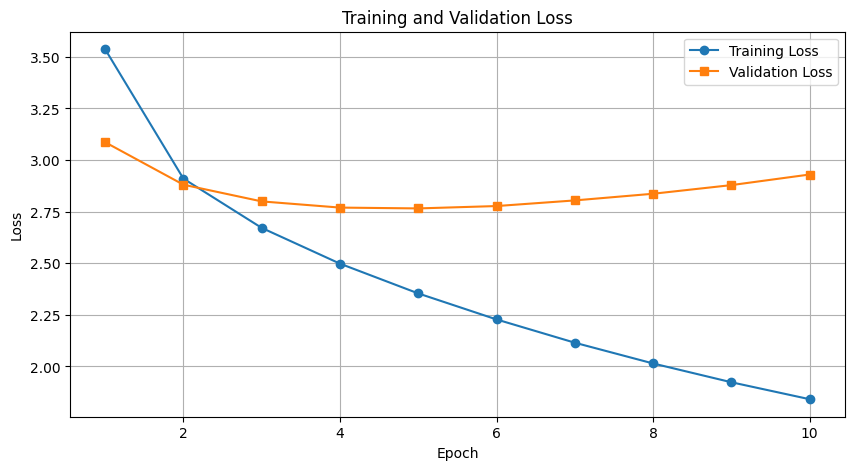

In [15]:
# ============================
# CELL 8: Loss plot
# ============================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**Greedy decoding function**

In [18]:
# ============================
# CELL 9: Greedy search for inference
# ============================

def greedy_decode(model, feature, max_len=20, start_idx=1, end_idx=2):
    model.eval()
    with torch.no_grad():
        feature = feature.unsqueeze(0).to(device)   # (1,2048)
        hidden = model.encoder(feature)             # (1, hidden_dim)
        h = hidden.unsqueeze(0)                    # (1,1,hidden_dim)
        c = torch.zeros_like(h)
        
        word = torch.tensor([start_idx]).to(device)  # start token
        caption_indices = [start_idx]
        
        for _ in range(max_len):
            embedded = model.decoder.embedding(word.unsqueeze(0))  # (1,1,embed_dim)
            lstm_out, (h, c) = model.decoder.lstm(embedded, (h, c))
            output = model.decoder.fc_out(lstm_out.squeeze(0))    # (1, vocab_size)
            pred = output.argmax(dim=1)                          # (1,)
            word_idx = pred.item()
            caption_indices.append(word_idx)
            if word_idx == end_idx:
                break
            word = torch.tensor([word_idx]).to(device)
        
        return caption_indices

**Beam search**

In [19]:
# ============================
# CELL 10: Beam search
# ============================

def beam_search_decode(model, feature, beam_width=3, max_len=20, start_idx=1, end_idx=2):
    model.eval()
    with torch.no_grad():
        feature = feature.unsqueeze(0).to(device)
        hidden = model.encoder(feature)
        h = hidden.unsqueeze(0)
        c = torch.zeros_like(h)
        
        # each element: [tokens, log_prob, (h, c)]
        sequences = [[[start_idx], 0.0, (h, c)]]
        completed = []
        
        for _ in range(max_len):
            all_candidates = []
            for tokens, score, (h_prev, c_prev) in sequences:
                if tokens[-1] == end_idx:
                    completed.append((tokens, score))
                    continue
                
                last_word = torch.tensor([tokens[-1]]).to(device)
                embedded = model.decoder.embedding(last_word.unsqueeze(0))
                lstm_out, (h_new, c_new) = model.decoder.lstm(embedded, (h_prev, c_prev))
                output = model.decoder.fc_out(lstm_out.squeeze(0))   # (1, vocab_size)
                log_probs = torch.log_softmax(output, dim=1)
                
                top_probs, top_indices = log_probs.topk(beam_width, dim=1)
                
                for i in range(beam_width):
                    word_idx = top_indices[0][i].item()
                    prob = top_probs[0][i].item()
                    new_tokens = tokens + [word_idx]
                    new_score = score + prob
                    all_candidates.append([new_tokens, new_score, (h_new, c_new)])
            
            # keep top beam_width overall
            ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
            sequences = ordered[:beam_width]
        
        # add remaining sequences
        for tokens, score, _ in sequences:
            completed.append((tokens, score))
        
        # choose the one with highest score
        best = max(completed, key=lambda x: x[1])
        return best[0]

**Evaluation: BLEU and token F1**

In [20]:
# ============================
# CELL 11: Evaluation metrics
# ============================

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt')  # just in case, but we use our tokenizer

def idxs_to_sentence(idxs):
    return [idx2word.get(i, '<unk>') for i in idxs if i not in [0,1,2,3]]  # remove special tokens

def compute_metrics(reference_tokens, hypothesis_tokens):
    # BLEU-4
    smooth = SmoothingFunction().method1
    bleu = sentence_bleu([reference_tokens], hypothesis_tokens, 
                         weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)
    
    # token-level precision, recall, F1 (set based)
    ref_set = set(reference_tokens)
    hyp_set = set(hypothesis_tokens)
    tp = len(ref_set & hyp_set)
    fp = len(hyp_set - ref_set)
    fn = len(ref_set - hyp_set)
    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)
    
    return bleu, precision, recall, f1

# Evaluate on test set using greedy
model.eval()
bleu_scores = []
precisions = []
recalls = []
f1s = []

for features, captions in test_loader:
    features = features.to(device)
    for i in range(features.size(0)):
        feature = features[i].cpu()  # take one image
        true_caption = captions[i].tolist()
        true_tokens = idxs_to_sentence(true_caption)
        
        # generate caption
        pred_idxs = greedy_decode(model, feature.to(device))
        pred_tokens = idxs_to_sentence(pred_idxs)
        
        bleu, prec, rec, f1 = compute_metrics(true_tokens, pred_tokens)
        bleu_scores.append(bleu)
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)

print(f"Average BLEU-4: {np.mean(bleu_scores):.4f}")
print(f"Average Precision: {np.mean(precisions):.4f}")
print(f"Average Recall: {np.mean(recalls):.4f}")
print(f"Average F1-score: {np.mean(f1s):.4f}")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Average BLEU-4: 0.0630
Average Precision: 0.3586
Average Recall: 0.3249
Average F1-score: 0.3293


**Show 5 random test images with captions**

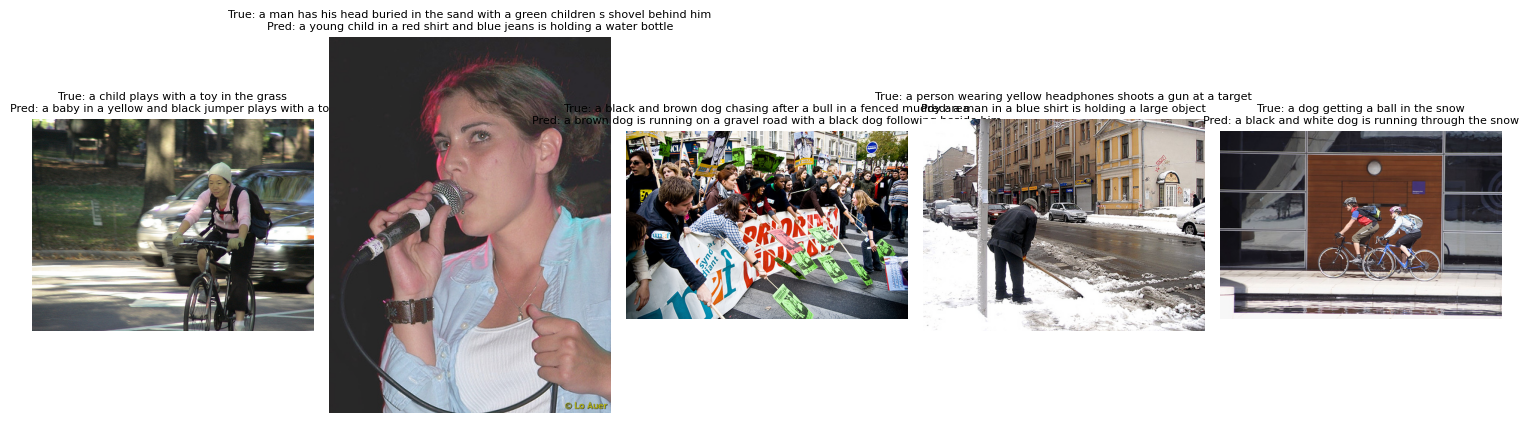

In [30]:
# ============================
# CELL 12: Visualize predictions
# ============================

import random
from PIL import Image
import matplotlib.pyplot as plt

# get 5 random indices from test_dataset
indices = random.sample(range(len(test_dataset)), 5)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(indices):
    feature, caption_tensor = test_dataset[idx]
    img_name = dataset.data_pairs[idx][0]   # get original image name
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = Image.open(img_path).convert('RGB')
    
    # ground truth caption
    true_indices = caption_tensor.tolist()
    true_caption = ' '.join(idxs_to_sentence(true_indices))
    
    # generate caption
    pred_indices = greedy_decode(model, feature.to(device))
    pred_caption = ' '.join(idxs_to_sentence(pred_indices))
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_caption}\nPred: {pred_caption}", fontsize=8)
plt.tight_layout()
plt.show()

**Deployment**

In [32]:
# ============================
# CELL 13: Streamlit app - VisualVerse
# ============================

app_code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import pickle

# ---------------------------------------------------------
# PAGE CONFIG - name your app here
# ---------------------------------------------------------
st.set_page_config(
    page_title="VisualVerse",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# ---------------------------------------------------------
# CUSTOM CSS - make it look clean and professional
# ---------------------------------------------------------
st.markdown("""
<style>
    /* main background - light gray */
    .stApp {
        background-color: #fafbfc;
    }
    /* container card */
    .main-card {
        background-color: white;
        border-radius: 16px;
        padding: 2rem 2rem 1.5rem 2rem;
        box-shadow: 0 4px 12px rgba(0,0,0,0.05);
        margin: 1rem auto;
        max-width: 1400px;
    }
    /* title styling */
    h1 {
        color: #1e2f4e;
        font-weight: 600;
        font-size: 2.5rem;
        margin-bottom: 0.2rem;
        letter-spacing: -0.5px;
    }
    /* subtitle */
    .subhead {
        color: #4a5e7a;
        font-size: 1.1rem;
        margin-bottom: 1.8rem;
        border-bottom: 1px solid #eaeef2;
        padding-bottom: 0.8rem;
    }
    /* upload area */
    .stFileUploader > div > div {
        border: 2px dashed #b8c5d0;
        border-radius: 12px;
        background-color: #f8fafc;
        padding: 2rem;
        transition: border 0.2s;
    }
    .stFileUploader > div > div:hover {
        border-color: #3a6ea5;
    }
    /* image caption */
    .caption-box {
        background-color: #f0f4fa;
        border-left: 5px solid #1e2f4e;
        border-radius: 8px;
        padding: 1.2rem 1.5rem;
        font-size: 1.2rem;
        font-weight: 450;
        color: #0e1c2a;
        margin-top: 0.5rem;
        line-height: 1.5;
    }
    /* footer */
    .footer {
        text-align: center;
        color: #6b7a8a;
        font-size: 0.85rem;
        margin-top: 2.5rem;
        border-top: 1px solid #e0e6ed;
        padding-top: 1.5rem;
    }
</style>
""", unsafe_allow_html=True)

# ---------------------------------------------------------
# LOAD MODEL (with simple caching)
# ---------------------------------------------------------
@st.cache(allow_output_mutation=True)
def load_model():
    # vocabulary
    with open('vocab.pkl', 'rb') as f:
        vocab = pickle.load(f)
        word2idx = vocab['word2idx']
        idx2word = vocab['idx2word']

    # ----- Encoder -----
    class Encoder(nn.Module):
        def __init__(self, input_dim=2048, hidden_dim=512):
            super().__init__()
            self.fc = nn.Linear(input_dim, hidden_dim)
            self.relu = nn.ReLU()
        def forward(self, x):
            return self.relu(self.fc(x))

    # ----- Decoder -----
    class Decoder(nn.Module):
        def __init__(self, vocab_size, embed_dim=256, hidden_dim=512):
            super().__init__()
            self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=word2idx['<pad>'])
            self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
            self.fc = nn.Linear(hidden_dim, vocab_size)
        def forward(self, caption, hidden):
            h0 = hidden.unsqueeze(0)
            c0 = torch.zeros_like(h0)
            emb = self.embed(caption)
            out, _ = self.lstm(emb, (h0, c0))
            return self.fc(out)

    # ----- Full model -----
    class CaptioningModel(nn.Module):
        def __init__(self, encoder, decoder):
            super().__init__()
            self.encoder = encoder
            self.decoder = decoder
        def forward(self, img_feat, caption):
            hid = self.encoder(img_feat)
            return self.decoder(caption, hid)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    encoder = Encoder()
    decoder = Decoder(len(word2idx))
    model = CaptioningModel(encoder, decoder).to(device)
    model.load_state_dict(torch.load('image_captioning_model.pth', map_location=device))
    model.eval()
    return model, word2idx, idx2word, device

model, word2idx, idx2word, device = load_model()

# ---------------------------------------------------------
# IMAGE PREPROCESSING
# ---------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406), (0.229,0.224,0.225))
])

# ---------------------------------------------------------
# CAPTION GENERATION (greedy)
# ---------------------------------------------------------
def generate_caption(image_tensor):
    with torch.no_grad():
        img_feat = model.encoder(image_tensor.unsqueeze(0).to(device))
        h = img_feat.unsqueeze(0)
        c = torch.zeros_like(h)
        word = torch.tensor([word2idx['<start>']]).to(device)
        caption_ids = []
        for _ in range(20):
            emb = model.decoder.embed(word.unsqueeze(0))
            out, (h, c) = model.decoder.lstm(emb, (h, c))
            logits = model.decoder.fc(out.squeeze(0))
            pred = logits.argmax(dim=1)
            wid = pred.item()
            if wid == word2idx['<end>']:
                break
            caption_ids.append(wid)
            word = torch.tensor([wid]).to(device)
        return ' '.join([idx2word[i] for i in caption_ids])

# ---------------------------------------------------------
# UI LAYOUT
# ---------------------------------------------------------
st.markdown('<div class="main-card">', unsafe_allow_html=True)

# App title
st.markdown("<h1>VisualVerse</h1>", unsafe_allow_html=True)
st.markdown('<p class="subhead">Transform images into descriptive text</p>', unsafe_allow_html=True)

# Two columns
col_left, col_right = st.columns([1, 1], gap="large")

with col_left:
    st.markdown("**Upload Image**")
    uploaded = st.file_uploader(
        " ",  # hidden label via whitespace trick
        type=['jpg','jpeg','png'],
        label_visibility="collapsed"
    )
    if uploaded:
        image = Image.open(uploaded).convert('RGB')
        st.image(image, caption=None, use_column_width=True)
    else:
        # placeholder box
        st.markdown("""
        <div style="background-color:#f8fafc; border-radius:12px; padding:3rem; text-align:center; border:1px dashed #b8c5d0;">
            <span style="font-size:40px; color:#6b7a8a;"></span>
            <p style="color:#4a5e7a; margin-top:0.5rem;">No image selected</p>
        </div>
        """, unsafe_allow_html=True)

with col_right:
    st.markdown("**Generated Caption**")
    if uploaded:
        with st.spinner("Generating caption ..."):
            img_tensor = transform(image)
            caption_text = generate_caption(img_tensor)
        st.markdown(f'<div class="caption-box">{caption_text}</div>', unsafe_allow_html=True)
        
        # small model info
        st.markdown("""
        <div style="background-color:#e9eef3; border-radius:6px; padding:0.6rem 1rem; margin-top:1rem; color:#2a4058; font-size:0.85rem;">
            <b>Model:</b> ResNet50 + LSTM (trained on Flickr30k)
        </div>
        """, unsafe_allow_html=True)
    else:
        st.markdown("""
        <div style="background-color:#f8fafc; border-radius:12px; padding:3rem; text-align:center; border:1px dashed #b8c5d0;">
            <span style="font-size:40px; color:#6b7a8a;"></span>
            <p style="color:#4a5e7a; margin-top:0.5rem;">Caption will appear here</p>
        </div>
        """, unsafe_allow_html=True)

st.markdown('<div class="footer">VisualVerse · Generative AI Assignment · PyTorch + Streamlit</div>', unsafe_allow_html=True)
st.markdown('</div>', unsafe_allow_html=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print(" App 'VisualVerse' saved. Run: streamlit run app.py")

 App 'VisualVerse' saved. Run: streamlit run app.py


In [33]:
import os
print("Files in /kaggle/working:")
print(os.listdir('/kaggle/working'))

Files in /kaggle/working:
['flickr30k_features.pkl', 'image_captioning_model.pth', '.virtual_documents', 'app.py', 'vocab.pkl']


In [34]:
from IPython.display import FileLink, FileLinks

# Create a download link for a single file
FileLink('app.py')

/kaggle/working/app.py

In [35]:
import zipfile
import os

# Create a ZIP file
with zipfile.ZipFile('project_files.zip', 'w') as zipf:
    zipf.write('app.py')
    zipf.write('vocab.pkl')
    zipf.write('image_captioning_model.pth')
    # optional: zipf.write('flickr30k_features.pkl')   # large file

# Generate download link for the ZIP
from IPython.display import FileLink
FileLink('project_files.zip')

/kaggle/working/project_files.zip

In [36]:
from IPython.display import FileLink
FileLink('vocab.pkl')

/kaggle/working/vocab.pkl